<a href="https://colab.research.google.com/github/ibtihal7alharbi-tech/ML-project/blob/main/sleep_disorder_risk_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI-Powered Sleep Health Prediction and Recommendation System

## Target 1: Sleep Disorder Risk Prediction
**Goal:** Predict `sleep_disorder_risk` using lifestyle, sleep, and health-related features.
## Target 2: Sleep Quality Score Prediction
**Goal:** Predict `sleep_quality_score` using daily habits, sleep behavior, and health-related features.

## Target 3: Felt Rested Classification
**Goal:** Predict whether a person will wake up feeling rested (`felt_rested`) based on sleep, lifestyle, and health-related features.

## Target 4: Personalized Bedtime Recommendation
**Goal:** Estimate sleep quality and use the predicted result to generate a personalized bedtime recommendation.

---

## Import Required Libraries

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    mean_absolute_error,
    r2_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11

## Load the Dataset

In [2]:
# Load the dataset
dataset_path = "sleep_health_dataset.csv"

df_raw = pd.read_csv(dataset_path)

# Clean column names
df_raw.columns = df_raw.columns.str.strip()

print(f"Loaded: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
df_raw.head()

Loaded: 100,000 rows × 32 columns


,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,...,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
0,1,29,Female,Driver,25.7,Japan,6.19,6.6,22.5,19.3,...,63,0,0,20.1,1.84,Autumn,Weekday,73.4,Healthy,0
1,2,55,Female,Software Engineer,22.0,USA,8.32,6.9,26.9,14.9,...,52,1,0,18.0,0.13,Winter,Weekend,99.4,Healthy,1
2,3,42,Male,Nurse,25.0,India,3.74,1.0,20.2,16.2,...,72,0,1,17.9,1.67,Spring,Weekend,2.5,Severe,0
3,4,37,Female,Student,29.5,India,6.79,6.4,17.7,17.7,...,71,0,0,19.1,2.37,Summer,Weekend,67.8,Healthy,0
4,5,23,Male,Lawyer,23.6,Spain,5.02,3.2,23.3,18.3,...,71,0,0,19.7,1.26,Summer,Weekday,38.1,Mild,0


## Understand the Data & Cleaning

In [3]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 32 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   gender                       100000 non-null  object 
 3   occupation                   100000 non-null  object 
 4   bmi                          100000 non-null  float64
 5   country                      100000 non-null  object 
 6   sleep_duration_hrs           100000 non-null  float64
 7   sleep_quality_score          100000 non-null  float64
 8   rem_percentage               100000 non-null  float64
 9   deep_sleep_percentage        100000 non-null  float64
 10  sleep_latency_mins           100000 non-null  int64  
 11  wake_episodes_per_night      100000 non-null  int64  
 12  caffeine_mg_before_bed       100000 non-null  int64  
 13  

In [4]:
# Summary statistics for numeric columns
df_raw.describe().round(1)

,person_id,age,bmi,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,...,nap_duration_mins,stress_score,work_hours_that_day,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,cognitive_performance_score,felt_rested
count,100000.0,100000.0,100000.0,100000.0,100000.0,100000.0,100000.0,100000.0,100000.0,100000.0,...,100000.0,100000.0,100000.0,100000.0,100000.0,100000.0,100000.0,100000.0,100000.0,100000.0
mean,50000.5,34.7,26.3,6.4,4.9,20.2,20.3,19.8,3.3,38.8,...,14.9,5.7,7.1,66.6,0.6,0.1,20.5,1.2,59.2,0.4
std,28867.7,11.0,4.5,1.3,1.5,3.4,4.3,7.6,1.9,69.4,...,21.4,1.6,3.5,7.2,0.5,0.3,2.9,0.8,22.2,0.5
min,1.0,18.0,16.0,3.0,1.0,10.0,5.0,1.0,0.0,0.0,...,0.0,1.0,0.0,45.0,0.0,0.0,15.0,-1.0,0.0,0.0
25%,25000.8,26.0,23.2,5.5,3.8,18.0,17.4,14.0,2.0,0.0,...,0.0,4.8,4.7,62.0,0.0,0.0,18.5,0.7,44.2,0.0
50%,50000.5,33.0,26.3,6.4,4.9,20.3,20.3,19.0,3.0,0.0,...,0.0,5.8,7.4,67.0,1.0,0.0,20.5,1.2,60.4,0.0
75%,75000.2,42.0,29.3,7.3,6.0,22.6,23.2,25.0,5.0,80.0,...,30.0,6.8,9.7,71.0,1.0,0.0,22.5,1.7,75.8,1.0
max,100000.0,69.0,45.0,10.5,10.0,30.0,30.0,58.0,8.0,400.0,...,116.0,10.0,18.0,99.0,1.0,1.0,28.0,3.0,100.0,1.0


In [5]:
df_raw.isnull().sum() # Check Missing Values

,0
person_id,0
age,0
gender,0
occupation,0
bmi,0
country,0
sleep_duration_hrs,0
sleep_quality_score,0
rem_percentage,0
deep_sleep_percentage,0


In [6]:
df_raw["sleep_disorder_risk"].value_counts()

,count
sleep_disorder_risk,
Healthy,54156
Mild,33479
Moderate,8299
Severe,4066


In [7]:
for col in df_raw.select_dtypes(include="object"):
    print(col, ":", df_raw[col].unique(),'\n')

gender : ['Female' 'Male' 'Other'] 

occupation : ['Driver' 'Software Engineer' 'Nurse' 'Student' 'Lawyer' 'Freelancer'
 'Manager' 'Doctor' 'Homemaker' 'Teacher' 'Retired' 'Sales'] 

country : ['Japan' 'USA' 'India' 'Spain' 'Brazil' 'Netherlands' 'UK' 'Germany'
 'South Korea' 'Australia' 'Canada' 'Italy' 'France' 'Sweden' 'Mexico'] 

chronotype : ['Morning' 'Neutral' 'Evening'] 

mental_health_condition : ['Healthy' 'Both' 'Depression' 'Anxiety'] 

season : ['Autumn' 'Winter' 'Spring' 'Summer'] 

day_type : ['Weekday' 'Weekend'] 

sleep_disorder_risk : ['Healthy' 'Severe' 'Mild' 'Moderate'] 



In [8]:
# Copy the original dataset
df = df_raw.copy()

# Drop ID column if it exists
df.drop(columns=["person_id"], inplace=True, errors="ignore")

# Clean text columns
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.lower().str.strip()

# Check remaining missing values
print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 0


In [9]:
# Detect and cap outliers selectively using IQR + domain-aware bounds

report = []

# Work on a copy to keep the original dataframe unchanged
df_capped = df.copy()

# Columns to EXCLUDE from capping
target_like_cols = [
    "sleep_disorder_risk",
    "sleep_quality_score",
    "felt_rested",
    "cognitive_performance_score",
    "person_id"
]

# Columns where capping is recommended
cap_cols = [
    "age",
    "bmi",
    "sleep_duration_hrs",
    "sleep_latency_mins",
    "rem_percentage",
    "deep_sleep_percentage",
    "heart_rate_resting_bpm"
]

# Optional domain-aware bounds to avoid unrealistic values
domain_bounds = {
    "age": (0, 100),
    "bmi": (10, 60),
    "sleep_duration_hrs": (0, 16),
    "sleep_latency_mins": (0, 180),
    "rem_percentage": (0, 100),
    "deep_sleep_percentage": (0, 100),
    "heart_rate_resting_bpm": (30, 200)
}

for col in cap_cols:
    if col in df_capped.columns and col not in target_like_cols:
        if pd.api.types.is_numeric_dtype(df_capped[col]) and df_capped[col].nunique() > 2:
            q1 = df_capped[col].quantile(0.25)
            q3 = df_capped[col].quantile(0.75)
            iqr = q3 - q1

            lower = q1 - 1.5 * iqr
            upper = q3 + 1.5 * iqr

            # Apply domain-aware bounds if available
            if col in domain_bounds:
                domain_lower, domain_upper = domain_bounds[col]
                lower = max(lower, domain_lower)
                upper = min(upper, domain_upper)

            outliers_before = ((df_capped[col] < lower) | (df_capped[col] > upper)).sum()

            if outliers_before > 0:
                df_capped[col] = df_capped[col].clip(lower, upper)

            outliers_after = ((df_capped[col] < lower) | (df_capped[col] > upper)).sum()

            report.append({
                "Column": col,
                "Outliers Before": int(outliers_before),
                "Outliers After": int(outliers_after),
                "Lower Bound": round(lower, 2),
                "Upper Bound": round(upper, 2)
            })

# Show capping report
capping_report = pd.DataFrame(report).sort_values(by="Outliers Before", ascending=False)
display(capping_report)

,Column,Outliers Before,Outliers After,Lower Bound,Upper Bound
6,heart_rate_resting_bpm,1299,0,48.50,84.50
4,rem_percentage,778,0,11.10,29.50
2,sleep_duration_hrs,545,0,2.92,9.88
5,deep_sleep_percentage,402,0,8.70,31.90
3,sleep_latency_mins,368,0,0.00,41.50
1,bmi,341,0,14.05,38.45
0,age,341,0,2.00,66.00


In [10]:
# Final data check
print("Shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Infinite values:", np.isinf(df.select_dtypes(include="number")).sum().sum())

Shape: (100000, 31)
Missing values: 0
Infinite values: 0


### Exploratory Data Analysis: Key Visual Insights

Sleep Disorder Risk

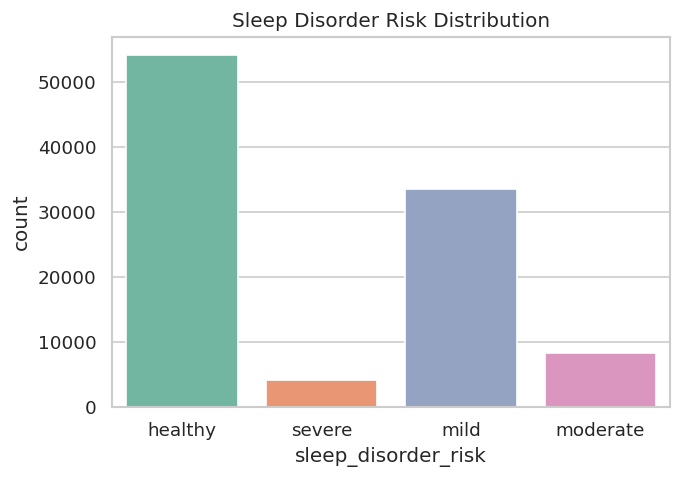

In [ ]:
# Sleep Disorder Risk Distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='sleep_disorder_risk', hue='sleep_disorder_risk', palette='Set2')
plt.title("Sleep Disorder Risk Distribution")
plt.show()

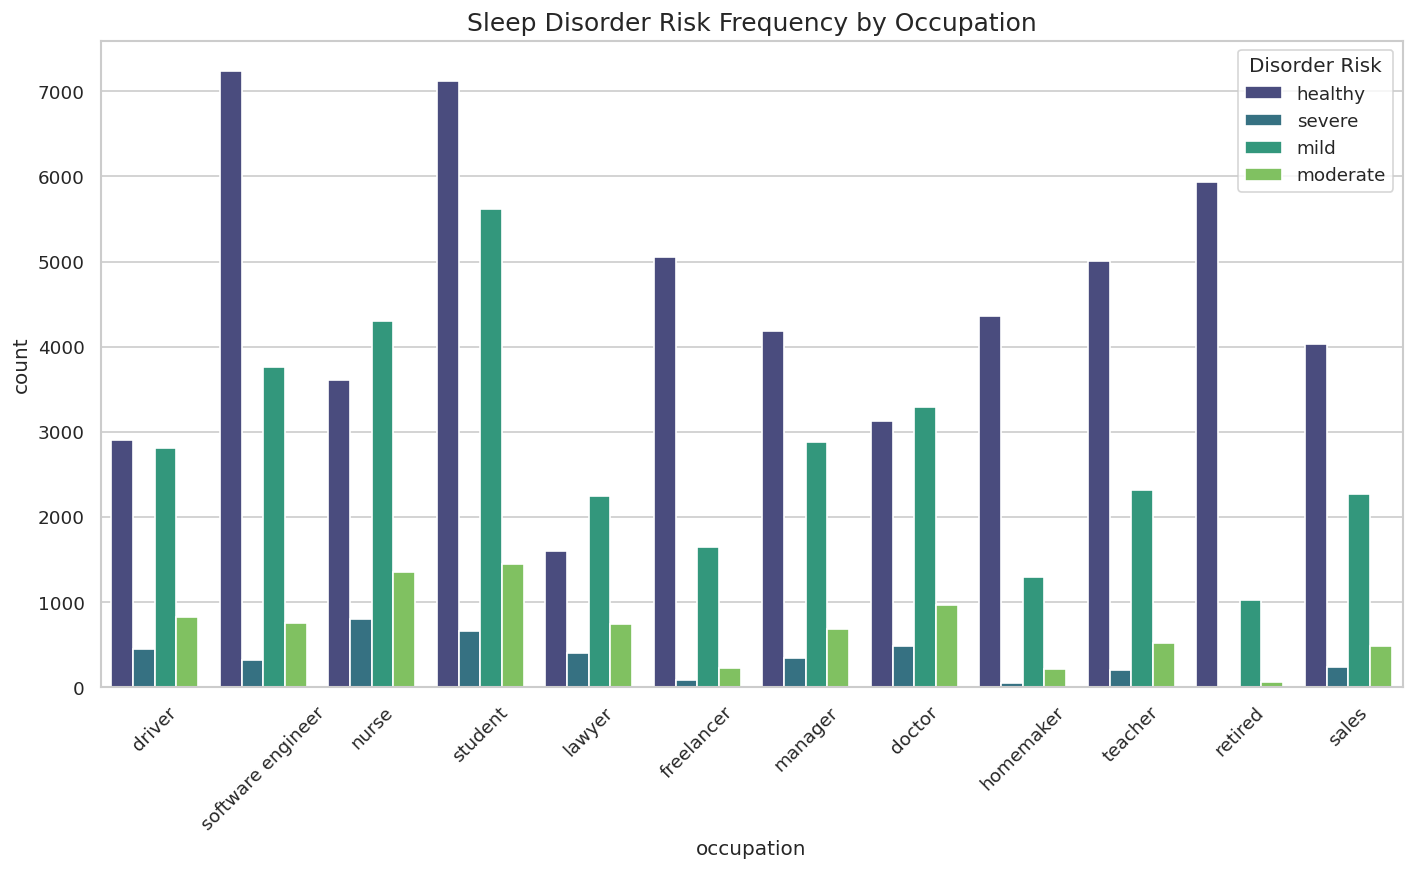

In [ ]:
# Sleep Disorder Risk Frequency by Occupation
plt.figure(figsize=(14, 7))
sns.countplot(data=df, x='occupation', hue='sleep_disorder_risk', palette='viridis')
plt.title('Sleep Disorder Risk Frequency by Occupation', fontsize=15)
plt.xticks(rotation=45)
plt.legend(title='Disorder Risk')
plt.show()

Sleep Quality Score

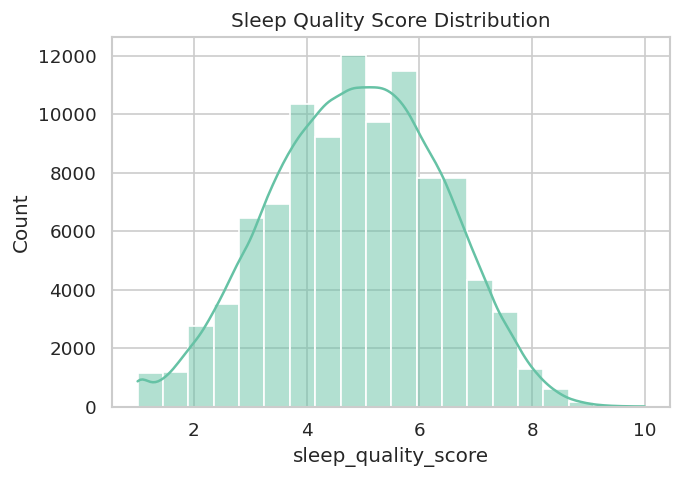

In [12]:
plt.figure(figsize=(6,4))
sns.histplot(df['sleep_quality_score'], kde=True, bins=20)
plt.title("Sleep Quality Score Distribution")
plt.show()

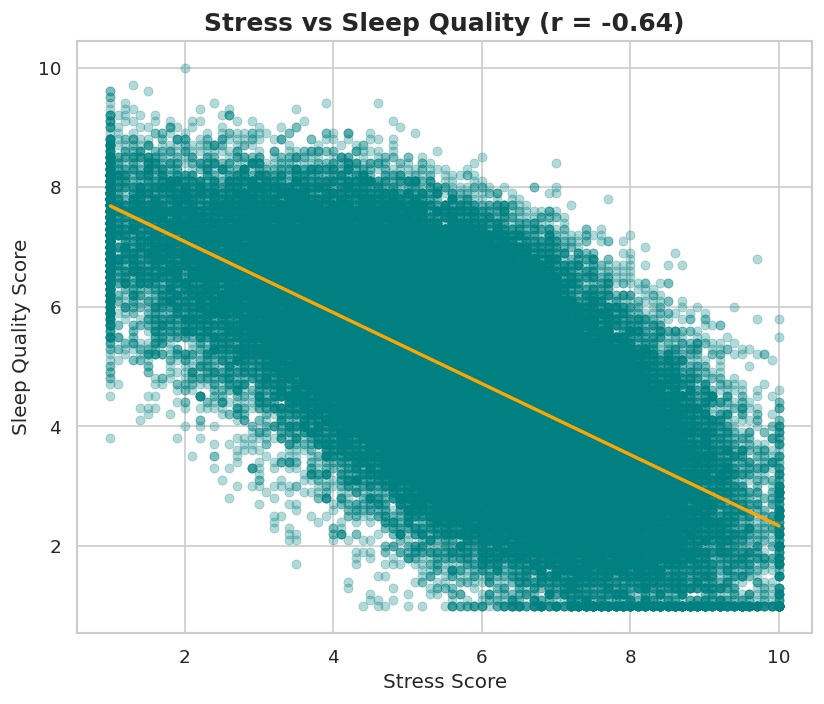

In [ ]:
# Stress vs Sleep Quality
plt.figure(figsize=(7,6))

sns.scatterplot(data=df, x='stress_score', y='sleep_quality_score', alpha=0.3, s=30, edgecolor=None, color='teal')

sns.regplot(data=df, x='stress_score', y='sleep_quality_score', scatter=False, color='orange',line_kws={'linewidth': 2})

corr = df['stress_score'].corr(df['sleep_quality_score'])

plt.title(f"Stress vs Sleep Quality (r = {corr:.2f})", fontsize=15, weight='bold')
plt.xlabel("Stress Score")
plt.ylabel("Sleep Quality Score")

plt.tight_layout()
plt.show()

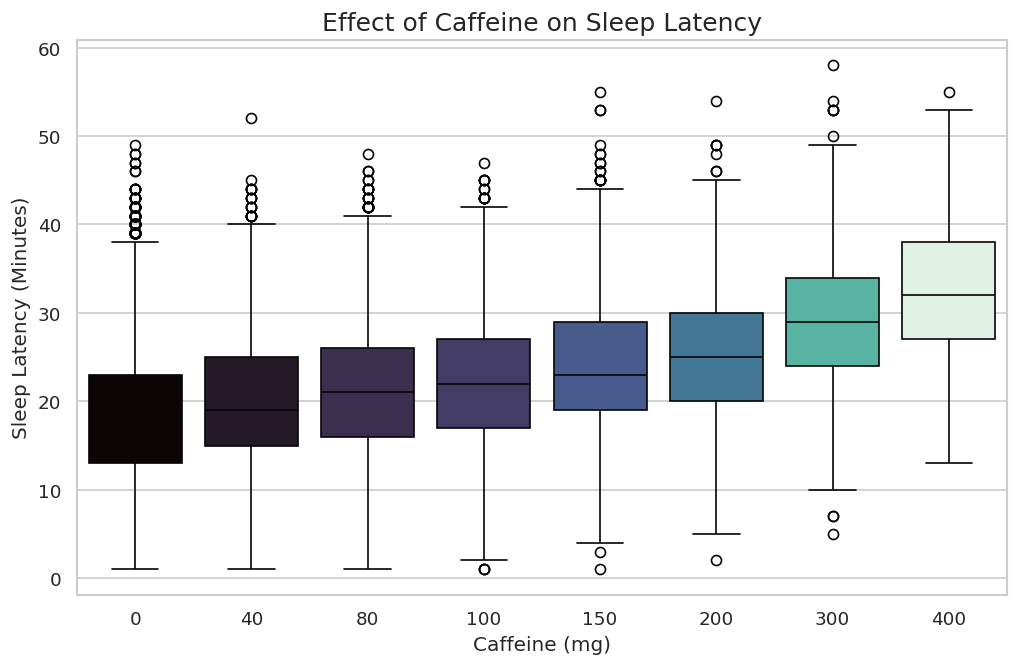

In [ ]:
# Effect of Caffeine on Sleep Latency
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='caffeine_mg_before_bed', y='sleep_latency_mins', hue='caffeine_mg_before_bed', palette='mako', legend=False)
plt.title('Effect of Caffeine on Sleep Latency', fontsize=15)
plt.xlabel('Caffeine (mg)')
plt.ylabel('Sleep Latency (Minutes)')
plt.show()

Felt Rested Classification

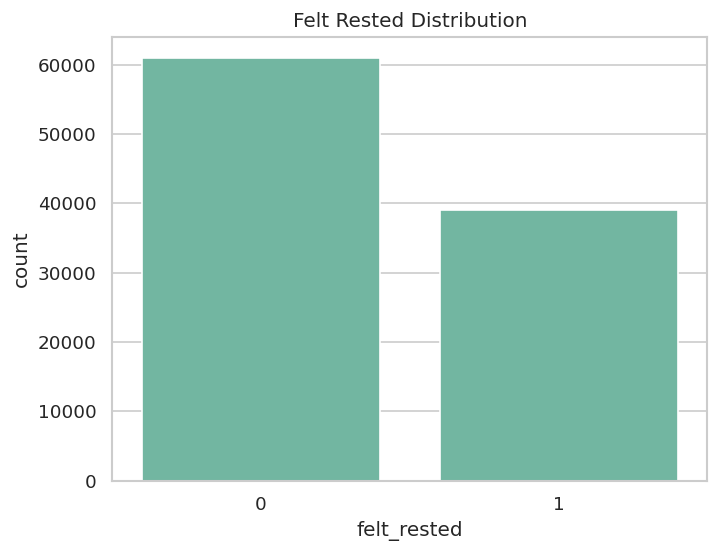

In [19]:
sns.countplot(x='felt_rested', data=df)
plt.title("Felt Rested Distribution")
plt.show()

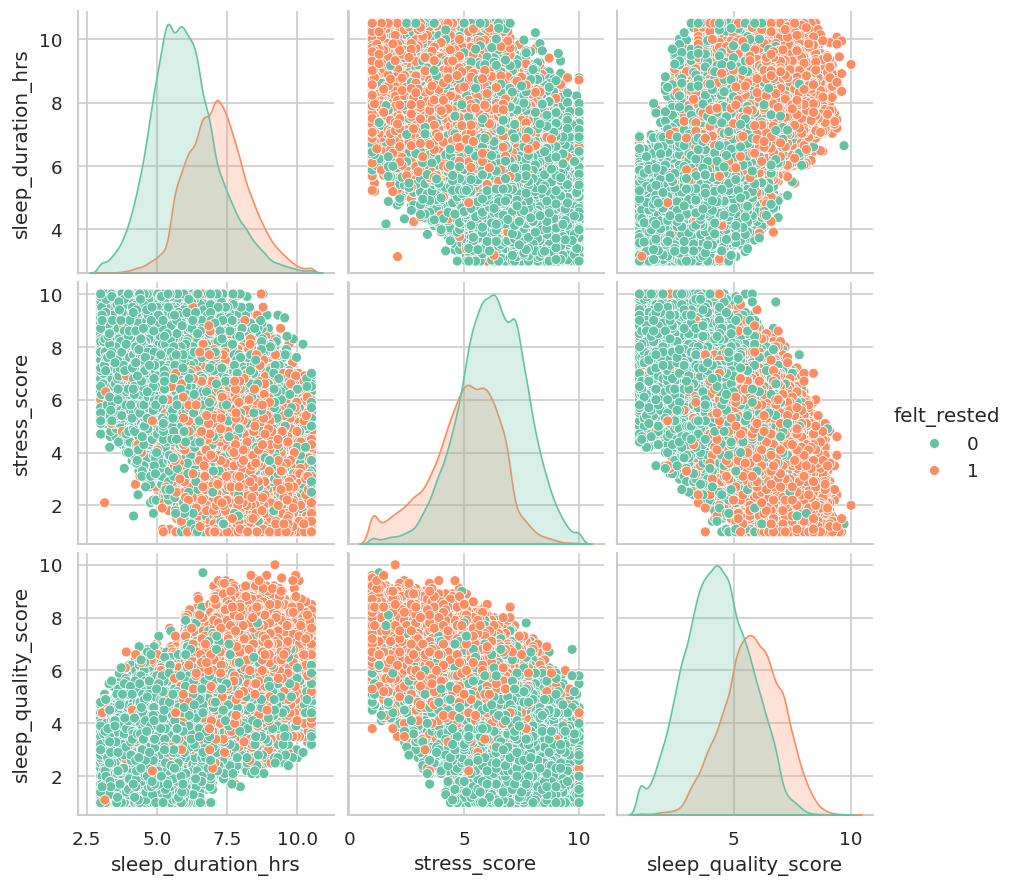

In [18]:
sns.pairplot(df[['sleep_duration_hrs','stress_score','sleep_quality_score','felt_rested']],
             hue='felt_rested')
plt.show()

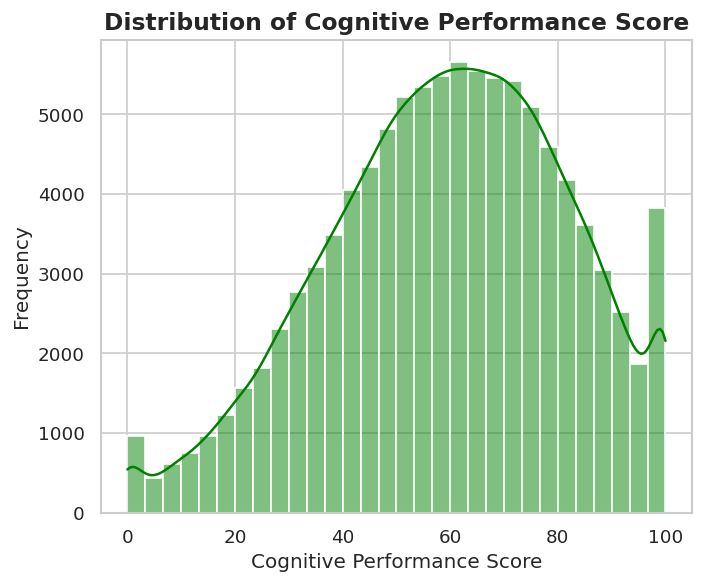

In [ ]:
# Distribution of Cognitive Performance
plt.figure(figsize=(6,5))

sns.histplot(data=df, x='cognitive_performance_score', bins=30, kde=True, color='Green')

plt.title("Distribution of Cognitive Performance Score", fontsize=14, weight='bold')
plt.xlabel("Cognitive Performance Score")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

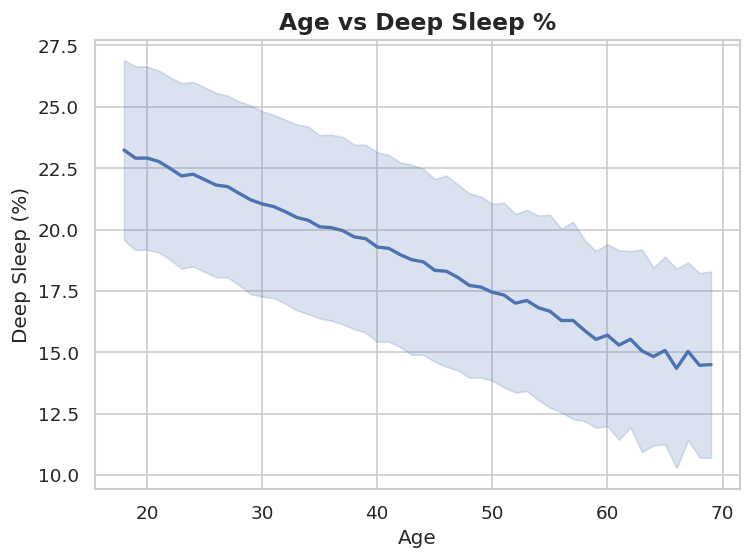

In [ ]:
# Age vs Deep Sleep
sns.lineplot(data=df, x='age', y='deep_sleep_percentage',errorbar='sd', color='#4C72B0', linewidth=2)

plt.title("Age vs Deep Sleep %", fontsize=14, weight='bold')
plt.xlabel("Age")
plt.ylabel("Deep Sleep (%)")

plt.tight_layout()
plt.show()

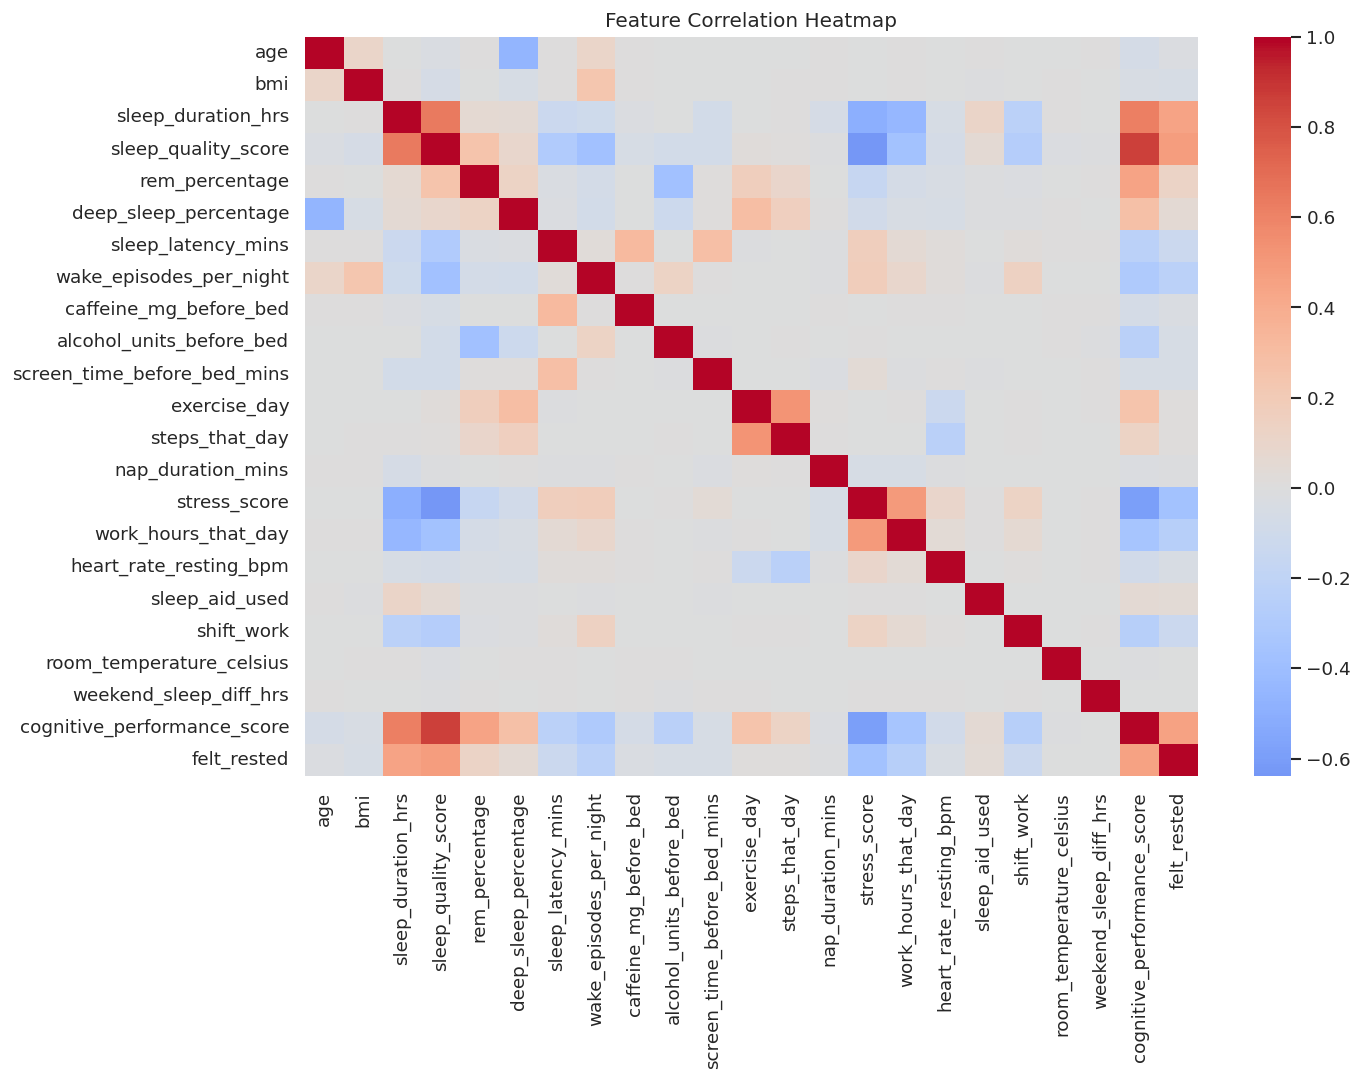

In [23]:
plt.figure(figsize=(12,8))
corr = df.select_dtypes(include='number').corr()

sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

## Feature Engineering

In [ ]:
# =========================
# Feature Engineering
# =========================

# Create a separate copy for machine learning
df_ml = df.copy()

# 1) Restorative Sleep Score
# Combines REM sleep and deep sleep percentages
# Higher values suggest more restorative sleep
df_ml["restorative_sleep_score"] = (
    df_ml["rem_percentage"] + df_ml["deep_sleep_percentage"]
)

# 2) Pre-Bed Stimulant Load
# Combines caffeine and alcohol intake before bed
# Each feature is normalized using its maximum value
df_ml["pre_bed_stimulant_load"] = (
    df_ml["caffeine_mg_before_bed"] / (df_ml["caffeine_mg_before_bed"].max() + 1)
    + df_ml["alcohol_units_before_bed"] / (df_ml["alcohol_units_before_bed"].max() + 1)
)

# 3) Sleep Debt Proxy
# Measures how much weekend sleep differs from regular sleep
# Larger values may indicate sleep compensation
df_ml["sleep_debt_proxy"] = df_ml["weekend_sleep_diff_hrs"].abs()

# 4) Sleep Disruption Score
# Combines major sleep disruption signals:
# stress, awakenings during the night, and sleep latency
df_ml["sleep_disruption_score"] = (
    df_ml["stress_score"] / (df_ml["stress_score"].max() + 1)
    + df_ml["wake_episodes_per_night"] / (df_ml["wake_episodes_per_night"].max() + 1)
    + df_ml["sleep_latency_mins"] / (df_ml["sleep_latency_mins"].max() + 1)
)

# List of newly created features
new_features = [
    "restorative_sleep_score",
    "pre_bed_stimulant_load",
    "sleep_debt_proxy",
    "sleep_disruption_score"
]

# Display a quick summary
print(f"{len(new_features)} new features created:")
print(df_ml[new_features].describe().round(3))

4 new features created:
       restorative_sleep_score  pre_bed_stimulant_load  sleep_debt_proxy  \
count               100000.000              100000.000        100000.000   
mean                    40.497                   0.182             1.245   
std                      5.769                   0.230             0.714   
min                     16.700                   0.000             0.000   
25%                     36.600                   0.000             0.690   
50%                     40.600                   0.100             1.200   
75%                     44.500                   0.286             1.740   
max                     60.000                   1.855             3.000   

       sleep_disruption_score  
count              100000.000  
mean                    1.229  
std                     0.321  
min                     0.126  
25%                     1.008  
50%                     1.220  
75%                     1.442  
max                     2.547  


## Target 1: Sleep Disorder Risk Classification

### Data Preprocessing for Sleep Disorder Risk Classification

In [ ]:
# Data Preprocessing
df_model = df_ml.copy()

target_col = "sleep_disorder_risk"

candidate_categorical_cols = [
    "gender", "occupation", "country", "chronotype",
    "mental_health_condition", "season", "day_type",
    "dur_bin", "stress_bin", "sq_bin", "age_bin"
]

categorical_cols = [col for col in candidate_categorical_cols if col in df_model.columns]

for col in categorical_cols:
    encoder = LabelEncoder()
    df_model[col] = encoder.fit_transform(df_model[col].astype(str))

target_encoder = LabelEncoder()
df_model[target_col] = target_encoder.fit_transform(df_model[target_col])

X = df_model.drop(columns=[target_col])
y = df_model[target_col]

# Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Model 1 — Random Forest Classifier


In [ ]:
# Model Building
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)


# Model Evaluation
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_encoder.classes_))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 86.41%

Classification Report:
              precision    recall  f1-score   support

     healthy       0.96      0.92      0.94     10831
        mild       0.83      0.82      0.82      6696
    moderate       0.56      0.71      0.63      1660
      severe       0.74      0.81      0.77       813

    accuracy                           0.86     20000
   macro avg       0.77      0.81      0.79     20000
weighted avg       0.87      0.86      0.87     20000


Confusion Matrix:
[[9951  880    0    0]
 [ 411 5491  787    7]
 [   0  253 1185  222]
 [   0    2  156  655]]


#### Feature Importance for Random Forest

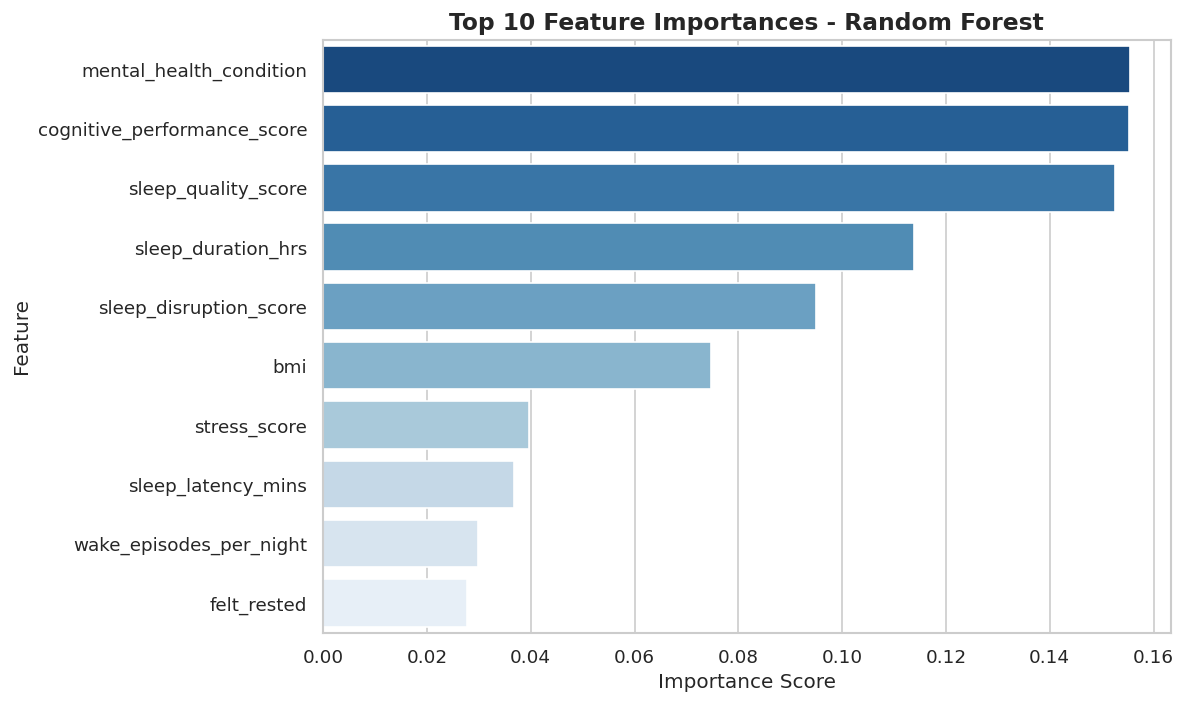

In [ ]:
# Extract feature importances from the trained Random Forest model
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

# Sort features by importance in descending order
feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

# Plot the top 10 most important features
plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature",
    palette="Blues_r"
)

plt.title("Top 10 Feature Importances - Random Forest", fontsize=14, fontweight="bold")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Model 2 — XGBoost

In [ ]:
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight

# Get the number of classes
num_classes = len(np.unique(y_train))

# Compute sample weights to handle class imbalance
sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)

# Build the XGBoost model
xgb_model = XGBClassifier(
    objective="multi:softprob",
    num_class=num_classes,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    random_state=42,
    tree_method="hist"
)

# Train the model
xgb_model.fit(X_train, y_train, sample_weight=sample_weights)

# Generate predictions
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate the model
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.2%}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=target_encoder.classes_))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

Accuracy: 93.65%

Classification Report:
              precision    recall  f1-score   support

     healthy       0.99      0.98      0.99     10831
        mild       0.94      0.91      0.92      6696
    moderate       0.66      0.82      0.73      1660
      severe       0.83      0.86      0.84       813

    accuracy                           0.94     20000
   macro avg       0.86      0.89      0.87     20000
weighted avg       0.94      0.94      0.94     20000


Confusion Matrix:
[[10607   224     0     0]
 [   54  6069   573     0]
 [    0   159  1357   144]
 [    0     0   116   697]]


### Model 3 — Hist Gradient Boosting Classifier

In [ ]:
from sklearn.utils.class_weight import compute_sample_weight

# Model Building
hgb_model = HistGradientBoostingClassifier(
    max_iter=200,
    learning_rate=0.05,
    max_depth=8,
    min_samples_leaf=20,
    random_state=42
)

# Compute sample weights for imbalanced classes
sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)

hgb_model.fit(X_train, y_train, sample_weight=sample_weights)
y_pred = hgb_model.predict(X_test)

# Model Evaluation
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_encoder.classes_))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 94.49%

Classification Report:
              precision    recall  f1-score   support

     healthy       1.00      0.99      0.99     10831
        mild       0.96      0.91      0.94      6696
    moderate       0.67      0.82      0.74      1660
      severe       0.82      0.85      0.84       813

    accuracy                           0.94     20000
   macro avg       0.86      0.90      0.88     20000
weighted avg       0.95      0.94      0.95     20000


Confusion Matrix:
[[10728   103     0     0]
 [   40  6109   547     0]
 [    0   139  1367   154]
 [    0     0   118   695]]


### Model Comparison ( Random Forest - XGBoost - Hist Gradient Boosting )

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Generate predictions for all models
rf_pred = rf_model.predict(X_test)
hgb_pred = hgb_model.predict(X_test)

# Build a comparison table for all models
comparison_table = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost", "HistGradientBoosting"],
    "Accuracy": [
        f"{accuracy_score(y_test, rf_pred):.2%}",
        f"{accuracy_score(y_test, y_pred_xgb):.2%}",
        f"{accuracy_score(y_test, hgb_pred):.2%}"
    ],
    "Weighted Precision": [
        f"{precision_score(y_test, rf_pred, average='weighted'):.2f}",
        f"{precision_score(y_test, y_pred_xgb, average='weighted'):.2f}",
        f"{precision_score(y_test, hgb_pred, average='weighted'):.2f}"
    ],
    "Weighted Recall": [
        f"{recall_score(y_test, rf_pred, average='weighted'):.2f}",
        f"{recall_score(y_test, y_pred_xgb, average='weighted'):.2f}",
        f"{recall_score(y_test, hgb_pred, average='weighted'):.2f}"
    ],
    "Weighted F1-Score": [
        f"{f1_score(y_test, rf_pred, average='weighted'):.2f}",
        f"{f1_score(y_test, y_pred_xgb, average='weighted'):.2f}",
        f"{f1_score(y_test, hgb_pred, average='weighted'):.2f}"
    ]
})

display(comparison_table)

,Model,Accuracy,Weighted Precision,Weighted Recall,Weighted F1-Score
0,Random Forest,86.41%,0.87,0.86,0.87
1,XGBoost,93.65%,0.94,0.94,0.94
2,HistGradientBoosting,94.49%,0.95,0.94,0.95


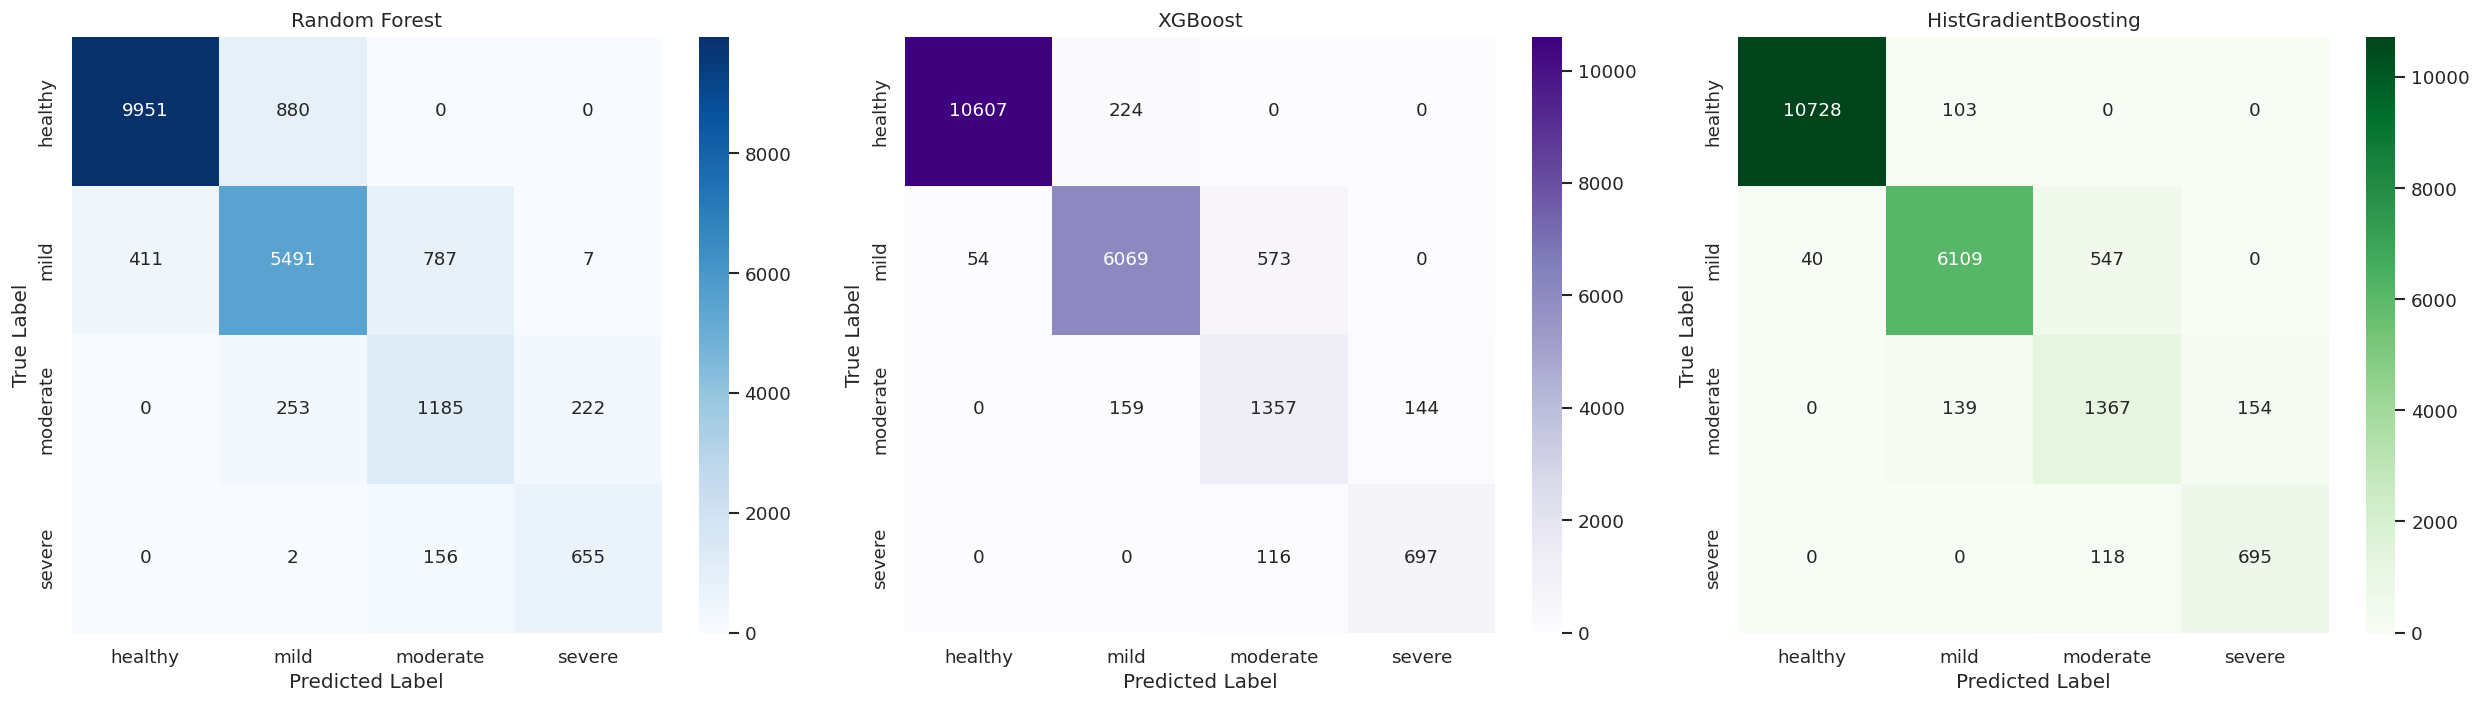

In [ ]:
# Generate predictions
rf_pred = rf_model.predict(X_test)
hgb_pred = hgb_model.predict(X_test)
xgb_pred = y_pred_xgb

# Compute confusion matrices
rf_cm = confusion_matrix(y_test, rf_pred)
xgb_cm = confusion_matrix(y_test, xgb_pred)
hgb_cm = confusion_matrix(y_test, hgb_pred)

# Class labels
class_names = target_encoder.classes_

# Create side-by-side plots
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# Random Forest
sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[0]
)
axes[0].set_title("Random Forest")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

# XGBoost
sns.heatmap(
    xgb_cm,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[1]
)
axes[1].set_title("XGBoost")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")

# HistGradientBoosting
sns.heatmap(
    hgb_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[2]
)
axes[2].set_title("HistGradientBoosting")
axes[2].set_xlabel("Predicted Label")
axes[2].set_ylabel("True Label")

plt.tight_layout()
plt.show()

## Target 2: Sleep Quality Score Prediction

### Data Preprocessing for Sleep Quality Score Prediction

In [ ]:
# Common Preprocessing

# Define the target
target_col = "sleep_quality_score"

# Drop target and target-like columns
drop_cols = [
    "sleep_quality_score",
    "cognitive_performance_score",
    "sleep_disorder_risk",
    "felt_rested",
    "person_id"
]

# Build features and target
X = df.drop(columns=drop_cols, errors="ignore")
y = df[target_col]

# Drop missing values consistently
data = X.copy()
data[target_col] = y
data.dropna(inplace=True)

X = data.drop(columns=[target_col])
y = data[target_col]

# Identify categorical columns for CatBoost
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

# Create train, validation, and test splits
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.1765, random_state=42
)

print("Training set shape:", X_train.shape)
print("Validation set shape:", X_val.shape)
print("Test set shape:", X_test.shape)
print("Categorical columns:", cat_cols)

Training set shape: (69997, 27)
Validation set shape: (15003, 27)
Test set shape: (15000, 27)
Categorical columns: ['gender', 'occupation', 'country', 'chronotype', 'mental_health_condition', 'season', 'day_type']


### Model 1 — Random Forest Regressor

In [ ]:
# Random Forest preprocessing
X_train_rf = pd.get_dummies(X_train, drop_first=False)
X_val_rf = pd.get_dummies(X_val, drop_first=False)
X_test_rf = pd.get_dummies(X_test, drop_first=False)

# Make sure all sets have the same columns
X_val_rf = X_val_rf.reindex(columns=X_train_rf.columns, fill_value=0)
X_test_rf = X_test_rf.reindex(columns=X_train_rf.columns, fill_value=0)

In [ ]:
# Build and train the model

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_rf, y_train)


# Validation evaluation

val_pred_rf = rf_model.predict(X_val_rf)

print("Validation Performance")
print(f"MAE: {mean_absolute_error(y_val, val_pred_rf):.4f}")
print(f"R²: {r2_score(y_val, val_pred_rf):.4f}")

# Final test evaluation

test_pred_rf = rf_model.predict(X_test_rf)

print("\nFinal Test Performance")
print(f"MAE: {mean_absolute_error(y_test, test_pred_rf):.4f}")
print(f"R²: {r2_score(y_test, test_pred_rf):.4f}")

Validation Performance
MAE: 0.5087
R²: 0.8232

Final Test Performance
MAE: 0.5064
R²: 0.8247


### Model 2 — CatBoost Regressor

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.5 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostRegressor

#  Define candidate parameters
candidate_params = [
    {"depth": 6, "learning_rate": 0.05, "l2_leaf_reg": 3, "bagging_temperature": 1},
    {"depth": 8, "learning_rate": 0.03, "l2_leaf_reg": 5, "bagging_temperature": 1},
    {"depth": 8, "learning_rate": 0.05, "l2_leaf_reg": 7, "bagging_temperature": 2},
    {"depth": 10, "learning_rate": 0.03, "l2_leaf_reg": 5, "bagging_temperature": 1},
]

# Variables to track the best model
results = []
best_model = None
best_r2 = -999
best_params = None

#  Train and evaluate each trial
for i, params in enumerate(candidate_params, start=1):
    model = CatBoostRegressor(
        iterations=2000,
        loss_function="RMSE",
        eval_metric="R2",
        random_seed=42,
        verbose=0,
        **params
    )

    # Train the model using training data
    # Use validation data for early stopping
    model.fit(
        X_train,
        y_train,
        cat_features=cat_cols,
        eval_set=(X_val, y_val),
        use_best_model=True,
        early_stopping_rounds=100
    )

    # Predict on validation set
    val_pred = model.predict(X_val)

    # Calculate validation metrics
    val_mae = mean_absolute_error(y_val, val_pred)
    val_r2 = r2_score(y_val, val_pred)

    # Save trial results
    results.append({
        "Trial": i,
        "Params": params,
        "Validation MAE": val_mae,
        "Validation R2": val_r2
    })

    # Keep the best model based on validation R²
    if val_r2 > best_r2:
        best_r2 = val_r2
        best_model = model
        best_params = params

# Show tuning results
results_df = pd.DataFrame(results).sort_values(by="Validation R2", ascending=False)
display(results_df)

print("Best Params:", best_params)
print(f"Best Validation R²: {best_r2:.4f}")

,Trial,Params,Validation MAE,Validation R2
1,2,"{'depth': 8, 'learning_rate': 0.03, 'l2_leaf_r...",0.486497,0.838605
0,1,"{'depth': 6, 'learning_rate': 0.05, 'l2_leaf_r...",0.486779,0.838499
2,3,"{'depth': 8, 'learning_rate': 0.05, 'l2_leaf_r...",0.486848,0.838390
3,4,"{'depth': 10, 'learning_rate': 0.03, 'l2_leaf_...",0.487400,0.837916


Best Params: {'depth': 8, 'learning_rate': 0.03, 'l2_leaf_reg': 5, 'bagging_temperature': 1}
Best Validation R²: 0.8386


In [ ]:
# Final test evaluation

test_pred = best_model.predict(X_test)

print("Final Test Performance")
print(f"MAE: {mean_absolute_error(y_test, test_pred):.4f}")
print(f"R²: {r2_score(y_test, test_pred):.4f}")

Final Test Performance
MAE: 0.4827
R²: 0.8405


### Model Comparison (  Random Forest Regressor - CatBoost Regressor )

In [ ]:
from sklearn.metrics import mean_squared_error

# Generate predictions for both models
rf_pred = rf_model.predict(X_test_rf)
catboost_pred = best_model.predict(X_test)

# Build a comparison table
comparison_table = pd.DataFrame({
    "Model": ["Random Forest", "CatBoost"],
    "MAE": [
        f"{mean_absolute_error(y_test, rf_pred):.4f}",
        f"{mean_absolute_error(y_test, catboost_pred):.4f}"
    ],
    "RMSE": [
        f"{np.sqrt(mean_squared_error(y_test, rf_pred)):.4f}",
        f"{np.sqrt(mean_squared_error(y_test, catboost_pred)):.4f}"
    ],
    "R² Score": [
        f"{r2_score(y_test, rf_pred):.4f}",
        f"{r2_score(y_test, catboost_pred):.4f}"
    ]
})

display(comparison_table)

,Model,MAE,RMSE,R² Score
0,Random Forest,0.5064,0.6332,0.8247
1,CatBoost,0.4827,0.6040,0.8405


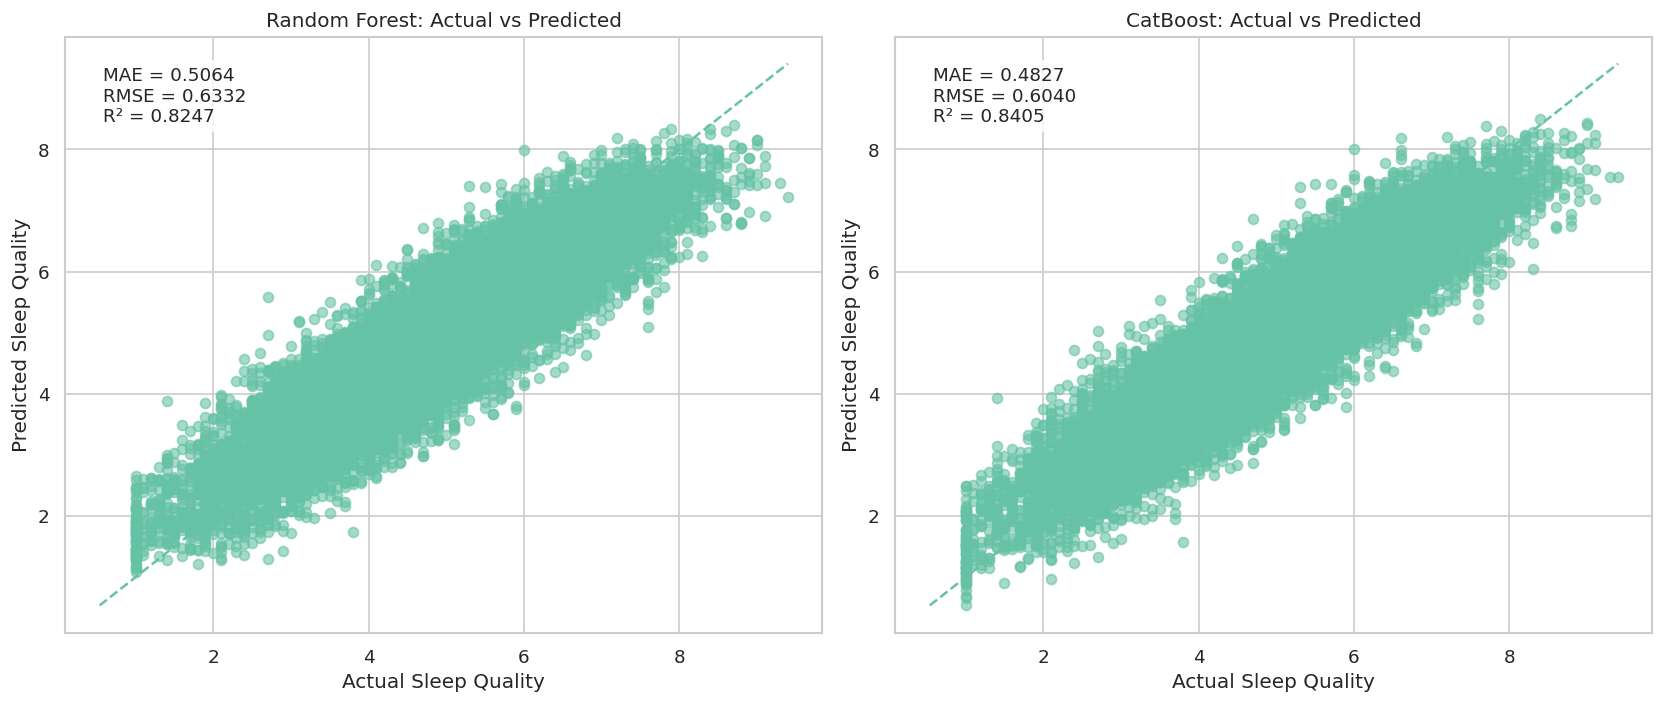

In [ ]:
# Predictions
rf_pred = rf_model.predict(X_test_rf)
catboost_pred = best_model.predict(X_test)

# Metrics
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

cb_mae = mean_absolute_error(y_test, catboost_pred)
cb_rmse = np.sqrt(mean_squared_error(y_test, catboost_pred))
cb_r2 = r2_score(y_test, catboost_pred)

# Limits for the diagonal reference line
min_val = min(y_test.min(), rf_pred.min(), catboost_pred.min())
max_val = max(y_test.max(), rf_pred.max(), catboost_pred.max())

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Random Forest
axes[0].scatter(y_test, rf_pred, alpha=0.6)
axes[0].plot([min_val, max_val], [min_val, max_val], linestyle="--")
axes[0].set_title("Random Forest: Actual vs Predicted")
axes[0].set_xlabel("Actual Sleep Quality")
axes[0].set_ylabel("Predicted Sleep Quality")
axes[0].text(
    0.05, 0.95,
    f"MAE = {rf_mae:.4f}\nRMSE = {rf_rmse:.4f}\nR² = {rf_r2:.4f}",
    transform=axes[0].transAxes,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

# CatBoost
axes[1].scatter(y_test, catboost_pred, alpha=0.6)
axes[1].plot([min_val, max_val], [min_val, max_val], linestyle="--")
axes[1].set_title("CatBoost: Actual vs Predicted")
axes[1].set_xlabel("Actual Sleep Quality")
axes[1].set_ylabel("Predicted Sleep Quality")
axes[1].text(
    0.05, 0.95,
    f"MAE = {cb_mae:.4f}\nRMSE = {cb_rmse:.4f}\nR² = {cb_r2:.4f}",
    transform=axes[1].transAxes,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.tight_layout()
plt.show()

## Target 3: Felt Rested Prediction

In [ ]:
# Common Preprocessing

# Define the target
target_col = "felt_rested"

# Drop target-like columns and identifier column
drop_cols = [
    "felt_rested",
    "sleep_disorder_risk",
    "cognitive_performance_score",
    "person_id"
]

# Build features and target
X3 = df.drop(columns=drop_cols, errors="ignore")
y3 = df[target_col]

# Drop missing values consistently
data3 = X3.copy()
data3[target_col] = y3
data3.dropna(inplace=True)

X3 = data3.drop(columns=[target_col])
y3 = data3[target_col]

# Identify categorical columns for CatBoost
cat_cols_3 = X3.select_dtypes(include=["object", "category"]).columns.tolist()

# Split the data
X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3,
    y3,
    test_size=0.2,
    random_state=42,
    stratify=y3
)

print("Training set shape:", X3_train.shape)
print("Test set shape:", X3_test.shape)
print("Categorical columns:", cat_cols_3)

Training set shape: (80000, 28)
Test set shape: (20000, 28)
Categorical columns: ['gender', 'occupation', 'country', 'chronotype', 'mental_health_condition', 'season', 'day_type']


### Model 1 — Logistic Regression

In [ ]:
# Logistic Regression Preprocessing

# Convert categorical columns into dummy variables
X3_train_lr = pd.get_dummies(X3_train, drop_first=False)
X3_test_lr = pd.get_dummies(X3_test, drop_first=False)

# Make sure test set has the same columns as training set
X3_test_lr = X3_test_lr.reindex(columns=X3_train_lr.columns, fill_value=0)

# Scale the features
scaler3 = StandardScaler()
X3_train_lr_s = scaler3.fit_transform(X3_train_lr)
X3_test_lr_s = scaler3.transform(X3_test_lr)

print("Logistic Regression training shape:", X3_train_lr_s.shape)
print("Logistic Regression test shape:", X3_test_lr_s.shape)

Logistic Regression training shape: (80000, 64)
Logistic Regression test shape: (20000, 64)


In [ ]:
# Build and train Logistic Regression

lr_model3 = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

lr_model3.fit(X3_train_lr_s, y3_train)

# Predict class labels
y3_pred_lr = lr_model3.predict(X3_test_lr_s)

# Predict probabilities for ROC-AUC
y3_pred_proba_lr = lr_model3.predict_proba(X3_test_lr_s)[:, 1]

# Evaluate the model
print("Logistic Regression Performance")
print(f"Accuracy: {accuracy_score(y3_test, y3_pred_lr):.4f}")
print(f"ROC-AUC: {roc_auc_score(y3_test, y3_pred_proba_lr):.4f}")
print("\nClassification Report:")
print(classification_report(y3_test, y3_pred_lr))

Logistic Regression Performance
Accuracy: 0.7316
ROC-AUC: 0.8126

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.73      0.77     12198
           1       0.63      0.74      0.68      7802

    accuracy                           0.73     20000
   macro avg       0.72      0.73      0.73     20000
weighted avg       0.74      0.73      0.73     20000



### Model 2 — CatBoost Classifier


In [ ]:
from catboost import CatBoostClassifier

# Build and train CatBoost Classifier

cb_model3 = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=100
)

cb_model3.fit(
    X3_train,
    y3_train,
    cat_features=cat_cols_3,
    eval_set=(X3_test, y3_test),
    use_best_model=True
)

# Predict class labels
y3_pred_cb = cb_model3.predict(X3_test)

# Predict probabilities for ROC-AUC
y3_pred_proba_cb = cb_model3.predict_proba(X3_test)[:, 1]

# Evaluate the model
print("CatBoost Classifier Performance")
print(f"Accuracy: {accuracy_score(y3_test, y3_pred_cb):.4f}")
print(f"ROC-AUC: {roc_auc_score(y3_test, y3_pred_proba_cb):.4f}")
print("\nClassification Report:")
print(classification_report(y3_test, y3_pred_cb))

0:	test: 0.8060537	best: 0.8060537 (0)	total: 363ms	remaining: 6m 2s
100:	test: 0.8258983	best: 0.8258983 (100)	total: 13.9s	remaining: 2m 3s
200:	test: 0.8260748	best: 0.8260748 (200)	total: 26.2s	remaining: 1m 44s
300:	test: 0.8262087	best: 0.8262446 (296)	total: 39.3s	remaining: 1m 31s
400:	test: 0.8261532	best: 0.8262446 (296)	total: 52.6s	remaining: 1m 18s
500:	test: 0.8258989	best: 0.8262446 (296)	total: 1m 6s	remaining: 1m 6s
600:	test: 0.8256835	best: 0.8262446 (296)	total: 1m 19s	remaining: 52.8s
700:	test: 0.8256541	best: 0.8262446 (296)	total: 1m 32s	remaining: 39.6s
800:	test: 0.8253689	best: 0.8262446 (296)	total: 1m 46s	remaining: 26.4s
900:	test: 0.8251086	best: 0.8262446 (296)	total: 2m 1s	remaining: 13.3s
999:	test: 0.8249015	best: 0.8262446 (296)	total: 2m 15s	remaining: 0us

bestTest = 0.8262445708
bestIteration = 296

Shrink model to first 297 iterations.
CatBoost Classifier Performance
Accuracy: 0.7432
ROC-AUC: 0.8262

Classification Report:
              precision

### Model Comparison (Logistic Regression - CatBoost Classifier)

In [ ]:
comparison_table_3 = pd.DataFrame({
    "Model": ["Logistic Regression", "CatBoost Classifier"],
    "Accuracy": [
        f"{accuracy_score(y3_test, y3_pred_lr):.4f}",
        f"{accuracy_score(y3_test, y3_pred_cb):.4f}"
    ],
    "Precision": [
        f"{precision_score(y3_test, y3_pred_lr, average='weighted'):.4f}",
        f"{precision_score(y3_test, y3_pred_cb, average='weighted'):.4f}"
    ],
    "Recall": [
        f"{recall_score(y3_test, y3_pred_lr, average='weighted'):.4f}",
        f"{recall_score(y3_test, y3_pred_cb, average='weighted'):.4f}"
    ],
    "F1-Score": [
        f"{f1_score(y3_test, y3_pred_lr, average='weighted'):.4f}",
        f"{f1_score(y3_test, y3_pred_cb, average='weighted'):.4f}"
    ],
    "ROC-AUC": [
        f"{roc_auc_score(y3_test, y3_pred_proba_lr):.4f}",
        f"{roc_auc_score(y3_test, y3_pred_proba_cb):.4f}"
    ]
})

display(comparison_table_3)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.7316,0.7436,0.7316,0.7344,0.8126
1,CatBoost Classifier,0.7432,0.7412,0.7432,0.7419,0.8262


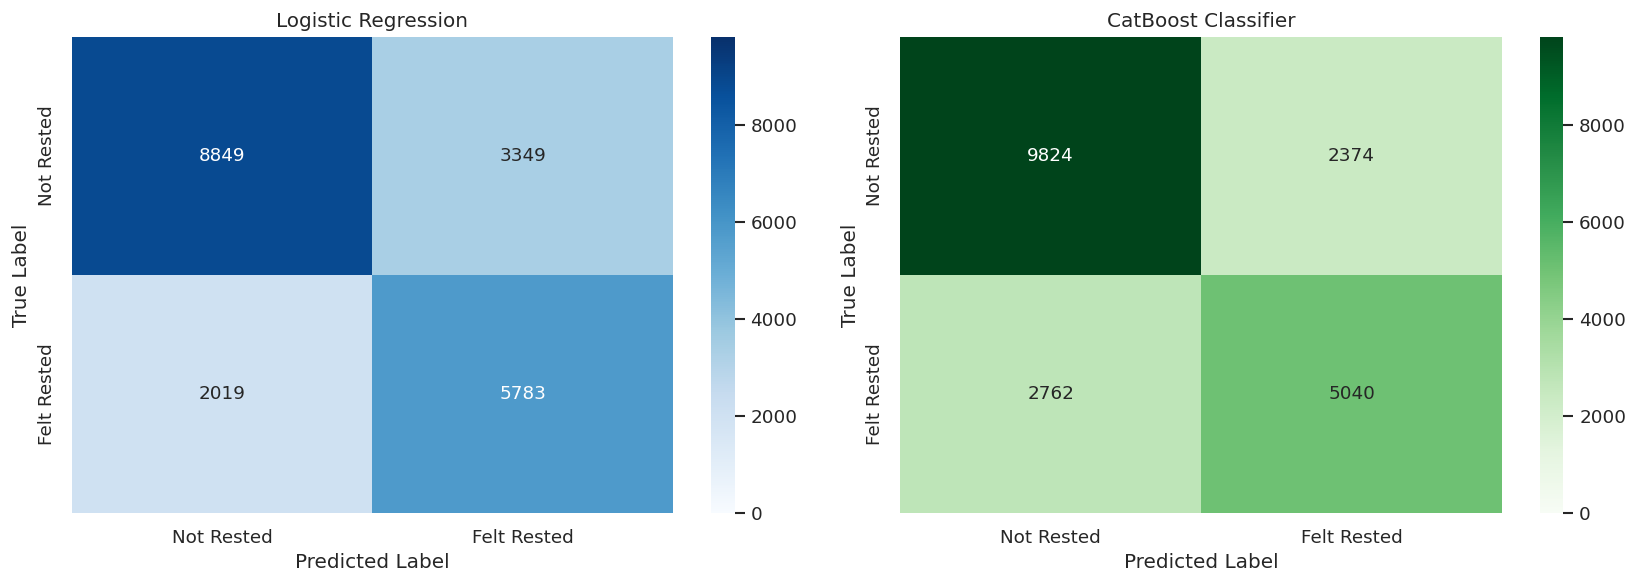

In [ ]:
# Confusion matrices
cm_lr = confusion_matrix(y3_test, y3_pred_lr)
cm_cb = confusion_matrix(y3_test, y3_pred_cb)

# Class names
class_names = ["Not Rested", "Felt Rested"]

# Use the same color scale for fair comparison
vmax = max(cm_lr.max(), cm_cb.max())

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True,
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[0],
    vmin=0,
    vmax=vmax
)
axes[0].set_title("Logistic Regression")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

sns.heatmap(
    cm_cb,
    annot=True,
    fmt="d",
    cmap="Greens",
    cbar=True,
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[1],
    vmin=0,
    vmax=vmax
)
axes[1].set_title("CatBoost Classifier")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")

plt.tight_layout()
plt.show()

## Target 4: Bedtime Recommendation based on Sleep Quality Prediction

In [ ]:
# Common Preprocessing

# Use df_ml if feature engineering was created, otherwise use df
source_df = df_ml.copy() if "df_ml" in globals() else df.copy()

# Define the target
target_col = "sleep_quality_score"

# Unified feature set for both models
base_features_bed = [
    "stress_score",
    "sleep_duration_hrs",
    "work_hours_that_day",
    "exercise_day",
    "bmi",
    "shift_work",
    "wake_episodes_per_night",
    "sleep_latency_mins",
    "chronotype"
]

# Add only the engineered features that are useful for this target
engineered_features_bed = [
    "pre_bed_stimulant_load",
    "sleep_debt_proxy"
]

# Keep only columns that actually exist
available_base = [col for col in base_features_bed if col in source_df.columns]
available_engineered = [col for col in engineered_features_bed if col in source_df.columns]

# Final unified feature list
features_bed = available_base + available_engineered

print("Selected features:")
print(features_bed)

# Build features and target
X_bed = source_df[features_bed].copy()
y_bed = source_df[target_col].copy()

# Drop missing values consistently across both models
bed_data = X_bed.copy()
bed_data[target_col] = y_bed
bed_data.dropna(inplace=True)

X_bed = bed_data[features_bed]
y_bed = bed_data[target_col]

# Identify categorical columns for CatBoost
cat_cols_bed = X_bed.select_dtypes(include=["object", "category"]).columns.tolist()

# Shared train / validation / test split
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_bed,
    y_bed,
    test_size=0.15,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.1765,
    random_state=42
)
# Final split ≈ 70% train, 15% validation, 15% test

print("\nTraining set shape:", X_train.shape)
print("Validation set shape:", X_val.shape)
print("Test set shape:", X_test.shape)
print("Categorical columns:", cat_cols_bed)

Selected features:
['stress_score', 'sleep_duration_hrs', 'work_hours_that_day', 'exercise_day', 'bmi', 'shift_work', 'wake_episodes_per_night', 'sleep_latency_mins', 'chronotype', 'pre_bed_stimulant_load', 'sleep_debt_proxy']

Training set shape: (69997, 11)
Validation set shape: (15003, 11)
Test set shape: (15000, 11)
Categorical columns: ['chronotype']


### Model 1 — Ridge Regressor

In [ ]:
from sklearn.linear_model import Ridge

# Ridge Preprocessing

# Convert categorical columns to dummy variables
X_train_ridge = pd.get_dummies(X_train, drop_first=False)
X_val_ridge = pd.get_dummies(X_val, drop_first=False)
X_test_ridge = pd.get_dummies(X_test, drop_first=False)

# Align validation and test columns with training columns
X_val_ridge = X_val_ridge.reindex(columns=X_train_ridge.columns, fill_value=0)
X_test_ridge = X_test_ridge.reindex(columns=X_train_ridge.columns, fill_value=0)

# Scale the features
scaler_bed = StandardScaler()
X_train_ridge_s = scaler_bed.fit_transform(X_train_ridge)
X_val_ridge_s = scaler_bed.transform(X_val_ridge)
X_test_ridge_s = scaler_bed.transform(X_test_ridge)


# Build and train Ridge model

ridge_model_bed = Ridge(alpha=1.0)
ridge_model_bed.fit(X_train_ridge_s, y_train)

# Validation predictions
ridge_val_pred = ridge_model_bed.predict(X_val_ridge_s)

print("Ridge Validation Performance")
print(f"MAE: {mean_absolute_error(y_val, ridge_val_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_val, ridge_val_pred)):.4f}")
print(f"R²: {r2_score(y_val, ridge_val_pred):.4f}")

Ridge Validation Performance
MAE: 0.7102
RMSE: 0.8857
R²: 0.6566


In [ ]:
# Test predictions
ridge_test_pred = ridge_model_bed.predict(X_test_ridge_s)

print("\nRidge Test Performance")
print(f"MAE: {mean_absolute_error(y_test, ridge_test_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, ridge_test_pred)):.4f}")
print(f"R²: {r2_score(y_test, ridge_test_pred):.4f}")


Ridge Test Performance
MAE: 0.7084
RMSE: 0.8858
R²: 0.6569


### Model 2 —  CatBoost Regressor

In [ ]:
# Build and train CatBoost model

catboost_bed = CatBoostRegressor(
    iterations=2000,
    depth=8,
    learning_rate=0.03,
    l2_leaf_reg=5,
    loss_function="RMSE",
    eval_metric="R2",
    random_seed=42,
    verbose=100
)

catboost_bed.fit(
    X_train,
    y_train,
    cat_features=cat_cols_bed,
    eval_set=(X_val, y_val),
    use_best_model=True,
    early_stopping_rounds=100
)

# Validation predictions
catboost_val_pred = catboost_bed.predict(X_val)

print("CatBoost Validation Performance")
print(f"MAE: {mean_absolute_error(y_val, catboost_val_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_val, catboost_val_pred)):.4f}")
print(f"R²: {r2_score(y_val, catboost_val_pred):.4f}")

0:	learn: 0.0385697	test: 0.0384834	best: 0.0384834 (0)	total: 77.1ms	remaining: 2m 34s
100:	learn: 0.7165018	test: 0.7146948	best: 0.7146948 (100)	total: 9.3s	remaining: 2m 54s
200:	learn: 0.7279079	test: 0.7240763	best: 0.7240763 (200)	total: 15.8s	remaining: 2m 21s
300:	learn: 0.7311675	test: 0.7253558	best: 0.7253558 (300)	total: 19.1s	remaining: 1m 47s
400:	learn: 0.7337964	test: 0.7258258	best: 0.7258258 (400)	total: 22.3s	remaining: 1m 28s
500:	learn: 0.7363693	test: 0.7261899	best: 0.7261955 (495)	total: 27s	remaining: 1m 20s
600:	learn: 0.7387160	test: 0.7262795	best: 0.7262795 (600)	total: 30.3s	remaining: 1m 10s
700:	learn: 0.7409009	test: 0.7263077	best: 0.7263127 (679)	total: 33.7s	remaining: 1m 2s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.7263127074
bestIteration = 679

Shrink model to first 680 iterations.
CatBoost Validation Performance
MAE: 0.6334
RMSE: 0.7907
R²: 0.7263


In [ ]:
# Test predictions
catboost_test_pred = catboost_bed.predict(X_test)

print("\nCatBoost Test Performance")
print(f"MAE: {mean_absolute_error(y_test, catboost_test_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, catboost_test_pred)):.4f}")
print(f"R²: {r2_score(y_test, catboost_test_pred):.4f}")


CatBoost Test Performance
MAE: 0.6266
RMSE: 0.7841
R²: 0.7311


### Model Comparison (Ridge Regressor - CatBoost Regressor)

In [ ]:
comparison_table_bed = pd.DataFrame({
    "Model": ["Ridge Regressor", "CatBoost Regressor"],
    "MAE": [
        f"{mean_absolute_error(y_test, ridge_test_pred):.4f}",
        f"{mean_absolute_error(y_test, catboost_test_pred):.4f}"
    ],
    "RMSE": [
        f"{np.sqrt(mean_squared_error(y_test, ridge_test_pred)):.4f}",
        f"{np.sqrt(mean_squared_error(y_test, catboost_test_pred)):.4f}"
    ],
    "R² Score": [
        f"{r2_score(y_test, ridge_test_pred):.4f}",
        f"{r2_score(y_test, catboost_test_pred):.4f}"
    ]
})

display(comparison_table_bed)

,Model,MAE,RMSE,R² Score
0,Ridge Regressor,0.7084,0.8858,0.6569
1,CatBoost Regressor,0.6266,0.7841,0.7311


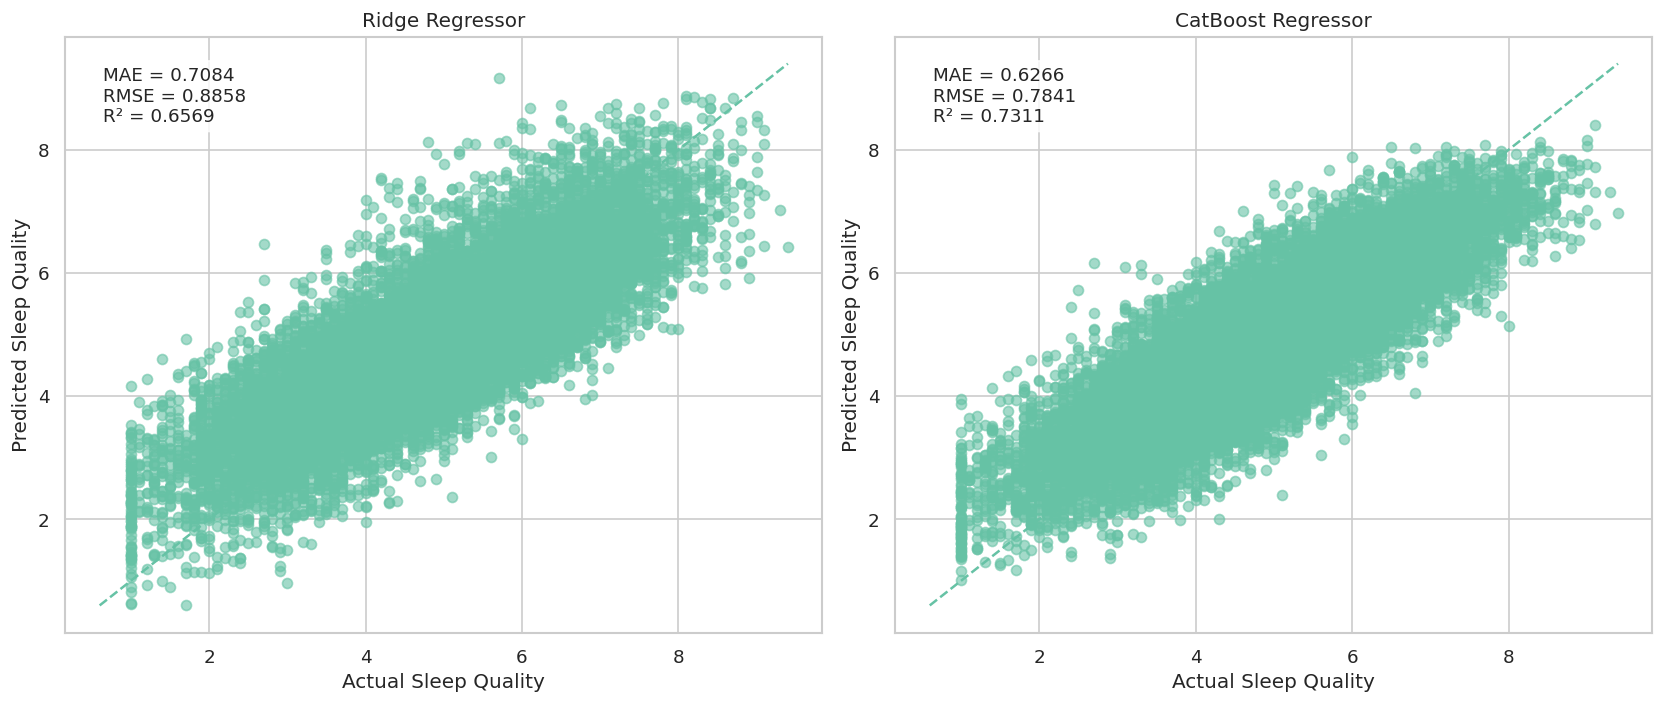

In [ ]:
# Create figure
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Common limits for fair comparison
min_val = min(y_test.min(), ridge_test_pred.min(), catboost_test_pred.min())
max_val = max(y_test.max(), ridge_test_pred.max(), catboost_test_pred.max())


# Ridge plot

axes[0].scatter(y_test, ridge_test_pred, alpha=0.6)
axes[0].plot([min_val, max_val], [min_val, max_val], linestyle="--")
axes[0].set_title("Ridge Regressor")
axes[0].set_xlabel("Actual Sleep Quality")
axes[0].set_ylabel("Predicted Sleep Quality")
axes[0].text(
    0.05, 0.95,
    f"MAE = {mean_absolute_error(y_test, ridge_test_pred):.4f}\n"
    f"RMSE = {np.sqrt(mean_squared_error(y_test, ridge_test_pred)):.4f}\n"
    f"R² = {r2_score(y_test, ridge_test_pred):.4f}",
    transform=axes[0].transAxes,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)


# CatBoost plot

axes[1].scatter(y_test, catboost_test_pred, alpha=0.6)
axes[1].plot([min_val, max_val], [min_val, max_val], linestyle="--")
axes[1].set_title("CatBoost Regressor")
axes[1].set_xlabel("Actual Sleep Quality")
axes[1].set_ylabel("Predicted Sleep Quality")
axes[1].text(
    0.05, 0.95,
    f"MAE = {mean_absolute_error(y_test, catboost_test_pred):.4f}\n"
    f"RMSE = {np.sqrt(mean_squared_error(y_test, catboost_test_pred)):.4f}\n"
    f"R² = {r2_score(y_test, catboost_test_pred):.4f}",
    transform=axes[1].transAxes,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.tight_layout()
plt.show()

In [ ]:
# Bedtime recommendation function using CatBoost

def recommend_bedtime(user_input, wake_up_time="07:00"):
    # Build input sample using the unified feature list
    sample = pd.DataFrame([{col: user_input.get(col, 0) for col in features_bed}])

    # Match categorical column types if needed
    for col in cat_cols_bed:
        if col in sample.columns:
            sample[col] = sample[col].astype(str)

    # Predict sleep quality
    quality = catboost_bed.predict(sample)[0]

    # Convert predicted sleep quality into bedtime recommendation
    ideal_hours = 7.0 if quality >= 7 else 7.5 if quality >= 5 else 8.5

    wake_h, wake_m = map(int, wake_up_time.split(":"))
    total = (wake_h * 60 + wake_m) - int(ideal_hours * 60)

    if total < 0:
        total += 1440

    bedtime_str = f"{(total // 60) % 24:02d}:{total % 60:02d}"

    return {
        "predicted_sleep_quality": round(float(quality), 2),
        "bedtime": bedtime_str,
        "ideal_hours": ideal_hours,
        "message": f"Go to sleep at {bedtime_str} to wake up at {wake_up_time} feeling great!"
    }